# 因果推論 入門 — Google Colab ハンズオン

経営情報各論BⅠ/EⅠ第13回 / 講義補助ノートブック

**問い:** 有料のオンライン講座を受けると、試験の点数は本当に上がるのか?

このノートブックでは、答え (真の因果効果 = **+5点**) を自分で仕込んだ
シミュレーションデータを作り、いくつかの手法がその答えを当てられるかを確かめます。

> **使い方:** 上のメニューから「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。
> 追加インストールは不要です(numpy / pandas / statsmodels / matplotlib はColabに最初から入っています)。

---

### 目次
1. データを作る ―「やる気」が交絡する世界
2. 素朴な平均差を見てみる(罠)
3. 層別化で「やる気」を揃える
4. 回帰調整で交絡を閉じる
5. 傾向スコアによる重み付け(IPW)
6. 仮想RCTで「正解」を確認する
7. まとめ・練習問題


## 0. 準備 — ライブラリの読み込み

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 日本語が文字化けする場合の保険(なくても数値結果には影響しません)
plt.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(42)   # 再現性のため乱数シードを固定
print("準備OK")

準備OK


## 1. データを作る ―「やる気」が交絡する世界

1000人の学生をシミュレーションします。鍵になるのは **やる気 (motivation)** で、これが

- **受講するかどうか (X)** … やる気が高い人ほど講座を受けやすい
- **試験の点数 (Y)** … やる気が高い人ほど点数も高い

の **両方** に影響します。これが「交絡因子 (confounder)」です。

真の因果効果 (講座そのものの効果) は **+5点** と仕込んでおきます。


In [ ]:
n = 1000

# 交絡因子: やる気 (0〜1の連続値)
motivation = rng.uniform(0, 1, n)

# やる気が高いほど受講しやすい (交絡経路 Z -> X)
p_take = 0.2 + 0.6 * motivation          # 受講確率は 0.2〜0.8
X = (rng.uniform(0, 1, n) < p_take).astype(int)

# 真の因果効果は +5点。点数は「やる気(+30)」「講座(+5)」+ノイズで決まる
true_effect = 5
Y = 50 + 30 * motivation + true_effect * X + rng.normal(0, 5, n)

df = pd.DataFrame(dict(motivation=motivation, X=X, Y=Y))
print(df.head())
print(f"\n受講した学生: {df.X.sum()}人 / 全{n}人")
print(f"仕込んだ真の因果効果: +{true_effect}点  ← これを各手法が当てられるか?")

   motivation  X          Y
0    0.773956  1  73.096037
1    0.438878  1  72.706667
2    0.858598  1  74.744455
3    0.697368  1  74.489210
4    0.094177  0  49.895062

受講した学生: 505人 / 全1000人
仕込んだ真の因果効果: +5点  ← これを各手法が当てられるか?


### 受講群と非受講群で「やる気」はどう違う?

ヒストグラムを見ると、受講した学生(オレンジ)の方がやる気の分布が右に寄っています。
**両群はそもそも別の集団** であることが視覚的に分かります。


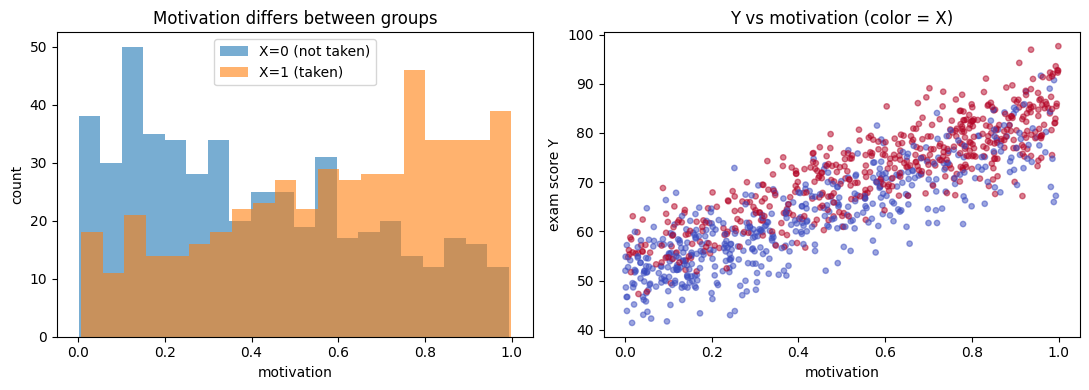

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df[df.X==0].motivation, bins=20, alpha=0.6, label="X=0 (not taken)")
ax[0].hist(df[df.X==1].motivation, bins=20, alpha=0.6, label="X=1 (taken)")
ax[0].set_xlabel("motivation"); ax[0].set_ylabel("count")
ax[0].set_title("Motivation differs between groups"); ax[0].legend()

ax[1].scatter(df.motivation, df.Y, c=df.X, cmap="coolwarm", alpha=0.5, s=15)
ax[1].set_xlabel("motivation"); ax[1].set_ylabel("exam score Y")
ax[1].set_title("Y vs motivation (color = X)")

plt.tight_layout(); plt.show()

## 2. 素朴な平均差を見てみる(罠)

まず一番ナイーブに、「受講した人の平均点 − 受講しなかった人の平均点」を計算します。


In [ ]:
mean_taken = df[df.X==1].Y.mean()
mean_not   = df[df.X==0].Y.mean()
naive_diff = mean_taken - mean_not

print(f"受講あり 平均点 : {mean_taken:.1f}")
print(f"受講なし 平均点 : {mean_not:.1f}")
print(f"素朴な差        : {naive_diff:.1f}  ← 真値+5よりずっと大きい!")

受講あり 平均点 : 72.9
受講なし 平均点 : 62.1
素朴な差        : 10.8  ← 真値+5よりずっと大きい!


**+14点くらい** になったはずです。真値は+5点なのに、大幅に過大評価しています。

理由は明確で、受講群はやる気が高く、その分の点差(交絡)が「講座の効果」に紛れ込んでいるからです。
次からはこの交絡を取り除いていきます。


## 3. 層別化で「やる気」を揃える

やる気を「高 / 低」の2グループに分け、**各グループの中だけ** で受講あり/なしを比べます。
そうすれば、比べる相手のやる気が近いので、差は講座の効果に近づきます。


In [ ]:
df["motiv_group"] = np.where(df.motivation >= df.motivation.median(), "高", "低")

rows = []
for g, sub in df.groupby("motiv_group"):
    m1 = sub[sub.X==1].Y.mean()
    m0 = sub[sub.X==0].Y.mean()
    rows.append({"やる気": g, "受講あり": round(m1,1), "受講なし": round(m0,1),
                 "群内の差": round(m1-m0,1), "人数": len(sub)})

strat = pd.DataFrame(rows)
print(strat.to_string(index=False))

# 各群の差を人数で重み付け平均 = 層別化によるATE推定
w = strat["人数"]
ate_strat = np.average(strat["群内の差"], weights=w)
print(f"\n層別化によるATE推定: {ate_strat:.1f}  (真値+5に接近)")

やる気  受講あり  受講なし  群内の差  人数
  低  63.4  56.7   6.7 500
  高  78.2  71.8   6.3 500

層別化によるATE推定: 6.5  (真値+5に接近)


群内の差はどちらも **+4〜+5点** 程度。全体差の +14点 の大半は「やる気の偏り」だったと分かります。
これは **シンプソンのパラドックス** の一例です。


## 4. 回帰調整で交絡を閉じる

層別化を連続変数のまま行うのが回帰です。やる気を説明変数に加え、
それを「一定」にした上での X の係数を読みます。


In [ ]:
m1 = smf.ols("Y ~ X", df).fit()                 # 調整なし
m2 = smf.ols("Y ~ X + motivation", df).fit()    # やる気で調整

print(f"調整なし  X係数 : {m1.params['X']:.2f}  (= 素朴な差とほぼ同じ)")
print(f"調整あり  X係数 : {m2.params['X']:.2f}  (真値+5にほぼ一致)")
print("\n--- 調整ありモデルの詳細 ---")
print(m2.summary().tables[1])

調整なし  X係数 : 10.78  (= 素朴な差とほぼ同じ)
調整あり  X係数 : 4.99  (真値+5にほぼ一致)

--- 調整ありモデルの詳細 ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.9788      0.324    154.295      0.000      49.343      50.614
X              4.9935      0.337     14.809      0.000       4.332       5.655
motivation    30.2613      0.578     52.313      0.000      29.126      31.396


`X` の係数が **14 → 5** へ。やる気を入れた瞬間に交絡経路が統計的に閉じられました。
95%信頼区間(`[0.025, 0.975]`列)も +5 を含んでいるはずです。


## 5. 傾向スコアによる重み付け(IPW)

**傾向スコア** = 「その人が受講する確率」。これをロジスティック回帰で推定し、
逆数で重み付け(IPW: Inverse Probability Weighting)すると、
やる気の偏りを補正した擬似的にバランスの取れた集団が作れます。


In [ ]:
import statsmodels.api as sm

# 傾向スコア e(x) = P(X=1 | motivation) をロジスティック回帰で推定
ps_model = smf.logit("X ~ motivation", df).fit(disp=False)
df["ps"] = ps_model.predict(df)

# IPW 重み: 受講群は 1/e, 非受講群は 1/(1-e)
df["w_ipw"] = np.where(df.X==1, 1/df.ps, 1/(1-df.ps))

# 重み付き平均の差 = ATE 推定
y1 = np.average(df[df.X==1].Y, weights=df[df.X==1].w_ipw)
y0 = np.average(df[df.X==0].Y, weights=df[df.X==0].w_ipw)
ate_ipw = y1 - y0
print(f"傾向スコア(IPW)によるATE推定: {ate_ipw:.1f}  (真値+5に接近)")

傾向スコア(IPW)によるATE推定: 4.9  (真値+5に接近)


## 6. 仮想RCTで「正解」を確認する

もし倫理やコストを気にせず **ランダムに** 受講を割り付けられたら?
やる気と無関係にコインを投げて X を決め直し、同じ点数モデルから Y を作り直します。
ランダム化したので、**素朴な差がそのまま因果効果** になります。


In [ ]:
X_rct = rng.integers(0, 2, n)   # コイン投げ(やる気と独立)

# 反事実を含む真の点数モデルから、割付に応じてYを生成
Y_rct = 50 + 30*motivation + true_effect*X_rct + rng.normal(0, 5, n)

ate_rct = Y_rct[X_rct==1].mean() - Y_rct[X_rct==0].mean()
print(f"RCTでのATE推定: {ate_rct:.1f}  (真値+5に一致 = 黄金律)")

RCTでのATE推定: 5.3  (真値+5に一致 = 黄金律)


In [ ]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 69.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=5a07f0b6146f58b7232888f26bba53892b64ba3628410c0a3b7070cde2470550
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


### 答え合わせ — 全手法を並べる

真の因果効果 = +5点

          手法  ATE推定値  真値との差
    素朴な差(観察)    10.8    5.8
     層別化(観察)     6.5    1.5
    回帰調整(観察)     5.0    0.0
傾向スコアIPW(観察)     4.9   -0.1
       仮想RCT     5.3    0.3


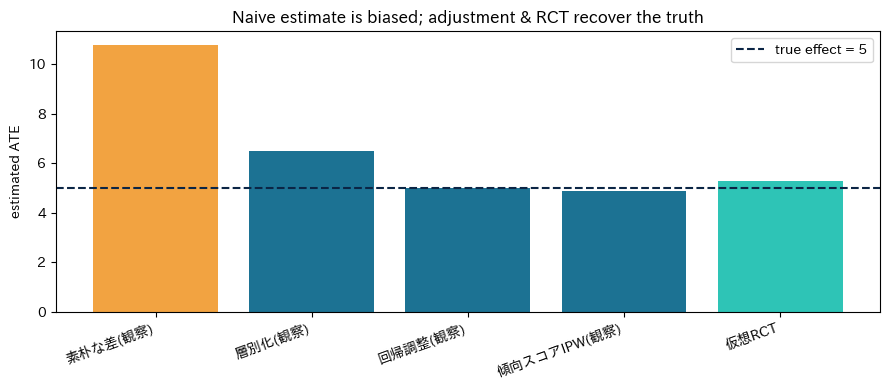

In [ ]:
import japanize_matplotlib
summary = pd.DataFrame({
    "手法": ["素朴な差(観察)", "層別化(観察)", "回帰調整(観察)",
             "傾向スコアIPW(観察)", "仮想RCT"],
    "ATE推定値": [round(naive_diff,1), round(ate_strat,1),
                  round(m2.params['X'],1), round(ate_ipw,1), round(ate_rct,1)],
})
summary["真値との差"] = (summary["ATE推定値"] - true_effect).round(1)
print(f"真の因果効果 = +{true_effect}点\n")
print(summary.to_string(index=False))

# 棒グラフで可視化
plt.figure(figsize=(9,4))
colors = ["#F2A341","#1C7293","#1C7293","#1C7293","#2EC4B6"]
plt.bar(summary["手法"], summary["ATE推定値"], color=colors)
plt.axhline(true_effect, color="#0B2545", ls="--", label=f"true effect = {true_effect}")
plt.ylabel("estimated ATE"); plt.xticks(rotation=20, ha="right")
plt.title("Naive estimate is biased; adjustment & RCT recover the truth")
plt.legend(); plt.tight_layout(); plt.show()

## 7. まとめ

| 手法 | 交絡への対処 | 前提 |
|---|---|---|
| 素朴な差 | なし(バイアスあり) | — |
| 層別化 | 交絡因子の値ごとに比較 | 交絡因子を観測・離散化できる |
| 回帰調整 | 交絡因子を一定にする | 関数形がだいたい正しい |
| 傾向スコア(IPW) | 受講確率で重み付け | 傾向スコアを正しく推定できる |
| RCT | ランダム化で経路を切断 | 実験が可能(黄金律) |

**最重要メッセージ**

- 観察データの手法はどれも「**測定できる交絡因子はすべて手元にある**」(条件付き独立)を前提とする。
- 未観測の交絡が残ると、どの調整法もバイアスを完全には取り除けない。
- だからこそ、可能ならランダム化(RCT)が最も信頼できる。

---

### 練習問題

1. `true_effect` を `0` に変えて全セルを再実行すると、各手法のATE推定はどうなる?
   (素朴な差は0でなく正の値が出るはず ― なぜ?)
2. やる気が点数に与える係数 `30` を `5` に下げると、素朴な差のバイアスはどう変わる?
3. 交絡因子をもう1つ(例: `study_hours`)追加し、X と Y の両方に影響させて、
   回帰に入れ忘れたときと入れたときで X の係数を比べてみよう。
4. `motivation` を回帰式から**わざと外した** `Y ~ X` だけのモデルでは、
   なぜ交絡を補正できないのか、DAG(やる気→X, やる気→Y)を描いて説明しよう。
